In [1]:
import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("xtr_estimator")
homepath = os.sep.join(path_parts[:idx ]) +"/occupancy-estimation/"
print(homepath)
sys.path.insert(0,homepath)

%load_ext autoreload 
%autoreload 2


/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/


In [2]:
import gemmi
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import reciprocalspaceship as rs
from meteor import rsmap
from meteor.sfcalc import gemmi_structure_to_calculated_map
from xtr_estimator.configuration import load_homepath
from xtr_estimator.logger import setup_logger
%load_ext autoreload
%autoreload 2
logger = setup_logger()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from xtr_estimator.alternative_methods import cleanup_data
from xtr_estimator.alternative_methods import prepare_data

In [4]:
from create_noisy_synth_data import get_paths
folder_paths = get_paths("poisson")

2026-04-17 20:42:10,319: xtr_estimator.logger: WARNING: Used threshold for posmask: 0.117, found 463 blobs (masking.py:144)
2026-04-17 20:42:10,323: xtr_estimator.logger: INFO: Using blobs with more than 22.00452891919375(3.0 A^3) voxels (masking.py:161)
2026-04-17 20:42:10,324: xtr_estimator.logger: INFO: Maximum Blob sizes found: 189 (masking.py:162)
2026-04-17 20:42:10,345: xtr_estimator.logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (7, 7, 7), considering a total of 92 voxels (control via 'blocking_radius' parameter) (masking.py:193)
2026-04-17 20:42:10,535: xtr_estimator.logger: INFO: Excluding 138 (10.38%) voxels from mask due to positive density within 1.5 A and above the 95.0 percentile (control via 'blocking_radius' and 'blocking_percentile' parameters) (masking.py:207)
2026-04-17 20:42:10,566: xtr_estimator.logger: INFO: Excluding an addtional 0 voxels from mask due to being in solvent (deactivate via 'exclude_solvent'

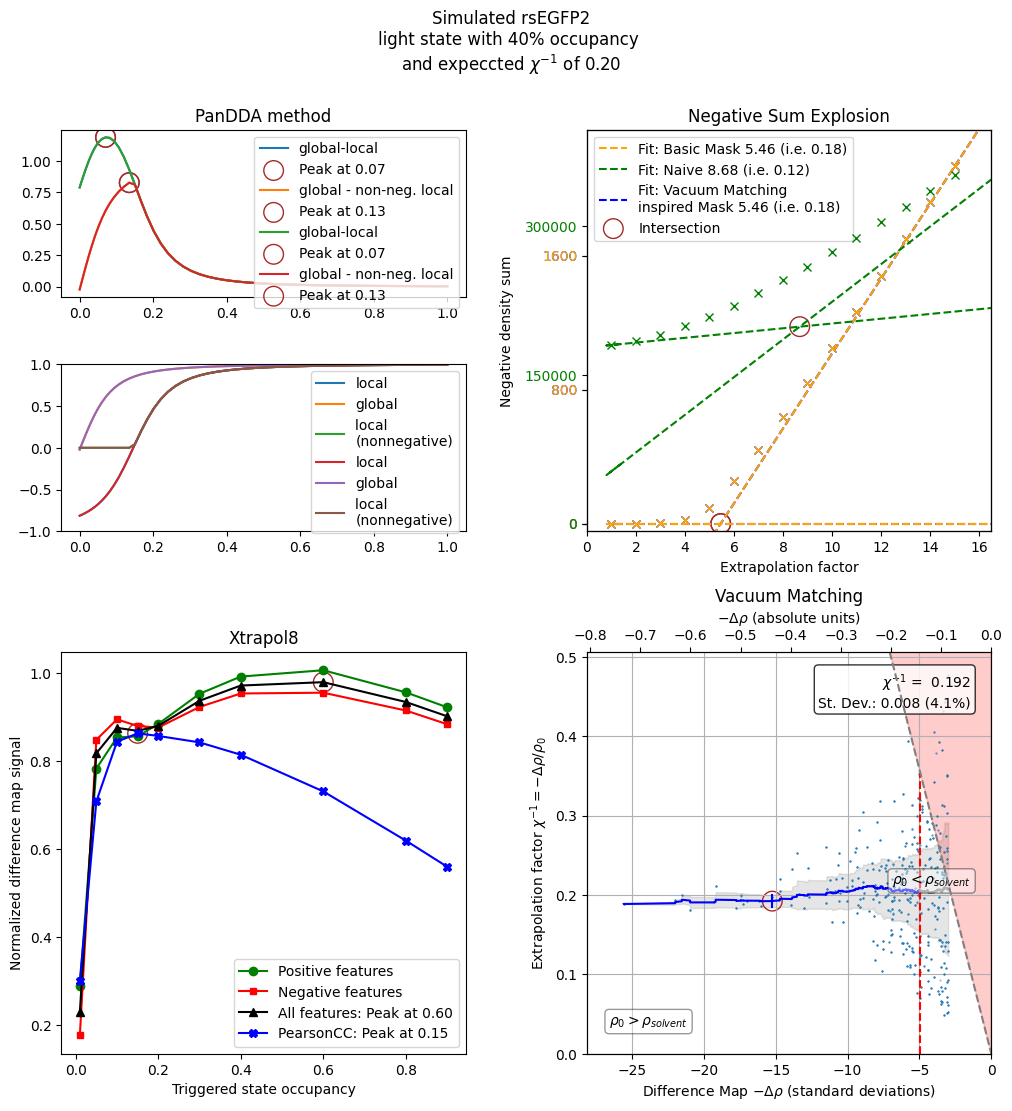

In [5]:
from create_noisy_synth_data import make_string
from xtr_estimator.alternative_methods import make_single_figure
reference_pdb =  "../data/rsEGFP2/trans.pdb"
dmin = 1.6

struc_dark = gemmi.read_pdb(reference_pdb)
map_dark_comp = gemmi_structure_to_calculated_map(
    struc_dark, high_resolution_limit=dmin,
)

options = dict(
    noise_type = "flat_solvent",
    
    attempt_no = 0,
    snr_factor = 15,
    occupancy_level = 0.4,
)
folder_loc = make_string(options)
folder_path = {folder_loc: options}
# folder_path = {"../occupancy-estimation/" + folder_loc: options}

# %matplotlib widget
data = prepare_data(folder_path, reference_pdb, dmin)
make_single_figure(data)

In [ ]:
import pandas as pd
import numpy as np
from logger import setup_logger

# Initialize logger

from alternative_methods import prepare_data, run_parallel_processing

noise_type="real_solvent"
noise_type="flat_solvent"
# noise_type="floor"
df_name = f"all_methods_{noise_type}.csv"
if os.path.exists(df_name):
    results_df = pd.read_csv(df_name)
else:
    folder_paths = get_paths(noise_type=noise_type)
        
    results_df = run_parallel_processing(
        folder_paths=folder_paths,
        reference_pdb=reference_pdb, 
        dmin=dmin, 
        num_processes=None,
        # pool_it=False
    )

    results_df.to_csv(f"all_methods_{noise_type}.csv", index=False)


In [ ]:
results_df[np.logical_and(results_df["true_occupancy"] == 0.1, results_df["snr"] == 20)]

,type,snr,true_occupancy,attempt_no,panda_trad,pandda_imp,occ,occ_CC,simple_nse,advanced_nse,vacuum_mean,vacuum_std
40,flat_solvent,20.0,0.1,0,4.205011e-04,0.020433,0.40,0.10,0.120501,0.065707,0.056071,0.005529
41,flat_solvent,20.0,0.1,1,6.678892e-03,0.026683,0.10,0.10,0.115528,0.066325,0.051946,0.002655
42,flat_solvent,20.0,0.1,2,4.205011e-04,0.020433,0.05,0.10,0.131004,0.064902,0.052928,0.002792
43,flat_solvent,20.0,0.1,3,1.000000e-08,0.015015,0.05,0.10,0.149587,0.063169,0.044500,0.008444
44,flat_solvent,20.0,0.1,4,1.000000e-08,0.020433,0.05,0.10,0.140519,0.069430,0.052193,0.009327
45,flat_solvent,20.0,0.1,5,1.673812e-03,0.020433,0.30,0.10,0.144696,0.083954,0.046948,0.001324
46,flat_solvent,20.0,0.1,6,4.205011e-04,0.020433,0.05,0.10,0.087552,0.059890,0.050346,0.003625
47,flat_solvent,20.0,0.1,7,1.000000e-08,0.015015,0.10,0.15,0.136299,0.054540,0.042788,0.004149
48,flat_solvent,20.0,0.1,8,1.000000e-08,0.020433,0.05,0.10,0.125204,0.071202,0.057133,0.014446
49,flat_solvent,20.0,0.1,9,4.205011e-04,0.020433,0.30,0.10,0.130352,0.057965,0.043501,0.002951


In [ ]:
# from logger import setup_logger
# import pandas as pd


# logger_alt = setup_logger()
# logger_alt.setLevel(40)  # Set to ERROR level to suppress INFO/DEBUG messages
# noise_type = "floor"
# # noise_type = "flat_solvent"
# csv_loc = f"{homepath}paperplots/all_methods_{noise_type}.csv"
# if not Path(csv_loc).is_file():
#     folder_paths = get_paths(noise_type=noise_type)
#     output_dict_list = []
#     for folder_path in folder_paths:
#         try:
#             print("Processing folder: ", folder_path.keys())
#             data = prepare_data(folder_path, reference_pdb, dmin)
#             output = make_figure_vary_inside(data)
#             output_dict_list.append(output)

#         except (KeyError, ValueError, FileNotFoundError, RuntimeError) as e:
#             print("failed for ", folder_path)


#     ds = pd.DataFrame(output_dict_list)

#     ds.to_csv(csv_loc, index=False)
# else:    
#     print(csv_loc, " already exists. Loading data from CSV.")
#     ds = pd.read_csv(csv_loc)

Processing folder:  dict_keys(['flat_solvent/snr_5_occ_0.1_no0/'])
Processing folder:  dict_keys(['flat_solvent/snr_5_occ_0.1_no1/'])
Processing folder:  dict_keys(['flat_solvent/snr_5_occ_0.1_no2/'])
Processing folder:  dict_keys(['flat_solvent/snr_5_occ_0.1_no3/'])
Processing folder:  dict_keys(['flat_solvent/snr_5_occ_0.1_no4/'])
Processing folder:  dict_keys(['flat_solvent/snr_5_occ_0.1_no5/'])
Processing folder:  dict_keys(['flat_solvent/snr_5_occ_0.1_no6/'])
Processing folder:  dict_keys(['flat_solvent/snr_5_occ_0.1_no7/'])
Processing folder:  dict_keys(['flat_solvent/snr_5_occ_0.1_no8/'])
Processing folder:  dict_keys(['flat_solvent/snr_5_occ_0.1_no9/'])
Processing folder:  dict_keys(['flat_solvent/snr_7.5_occ_0.1_no0/'])
Processing folder:  dict_keys(['flat_solvent/snr_7.5_occ_0.1_no1/'])
Processing folder:  dict_keys(['flat_solvent/snr_7.5_occ_0.1_no2/'])
Processing folder:  dict_keys(['flat_solvent/snr_7.5_occ_0.1_no3/'])
Processing folder:  dict_keys(['flat_solvent/snr_7.5_o

In [29]:
ds_test=pd.DataFrame(output_dict_list)
ds_test

""


In [ ]:

import copy
# if False:
output_dict_list3 =  output_dict_list 
ds = pd.DataFrame(output_dict_list3)

In [ ]:
ds

,type,snr,true_occupancy,attempt_no,panda_trad,pandda_imp,occ,occ_CC,simple_nse,advanced_nse,vacuum_mean,vacuum_std
0,flat_solvent,2,0.1,0,1.000000e+00,1.000000,0.60,0.6,0.426939,NaN,NaN,NaN
1,flat_solvent,2,0.1,1,1.000000e-08,1.000000,0.40,0.6,0.442127,NaN,0.708099,0.359682
2,flat_solvent,2,0.1,2,1.000000e+00,1.000000,0.60,0.6,0.604162,NaN,0.775627,0.138883
3,flat_solvent,2,0.1,3,1.000000e+00,1.000000,0.60,0.6,0.396933,NaN,NaN,NaN
4,flat_solvent,2,0.1,4,1.000000e+00,1.000000,0.15,0.6,0.628610,NaN,1.168004,0.270553
...,...,...,...,...,...,...,...,...,...,...,...,...
494,flat_solvent,100,0.8,5,1.666456e-01,0.350319,0.90,0.9,0.281691,NaN,0.401126,0.005984
495,flat_solvent,100,0.8,6,1.504015e-01,0.350319,0.90,0.9,0.283033,NaN,0.394565,0.006751
496,flat_solvent,100,0.8,7,1.666456e-01,0.350319,0.90,0.8,0.282003,NaN,0.399453,0.006251
497,flat_solvent,100,0.8,8,1.666456e-01,0.350319,0.90,0.9,0.281521,NaN,0.398383,0.006403


In [ ]:
# ds.groupby(["snr", "type", "true_occupancy"]).count()
# ds.groupby(["true_occupancy"]).count()
# ds.groupby(["snr", "type", "true_occupancy"]).agg({
#     "panda_trad": "mean",
#     "pandda_imp": "mean",
#     "occ": "mean", 
ds = results_df
ds

NameError: name 'results_df' is not defined

Index(['type', 'snr', 'true_occupancy', 'attempt_no', 'panda_trad',
       'pandda_imp', 'occ', 'occ_CC', 'simple_nse', 'advanced_nse',
       'vacuum_mean', 'vacuum_std'],
      dtype='object')
   true_occupancy  snr   type vacuum_mean           advanced_nse            \
                                     mean       std         mean       std   
0             0.1    2  floor    0.794807  0.348170     0.603407  0.212200   
1             0.1    4  floor    0.331591  0.299867     0.367615  0.110626   
2             0.1    6  floor    0.438582  0.142377     0.478024  0.174538   
3             0.1    8  floor    0.316231  0.244097     0.349111  0.234162   
4             0.1   10  floor    0.071104  0.011514     0.254233  0.253532   
5             0.1   15  floor    0.056120  0.009616     0.112987  0.071066   
6             0.1   20  floor    0.059423  0.011664     0.067068  0.009421   
7             0.1   30  floor    0.058344  0.010730     0.056294  0.006767   
8             0.1   50  f

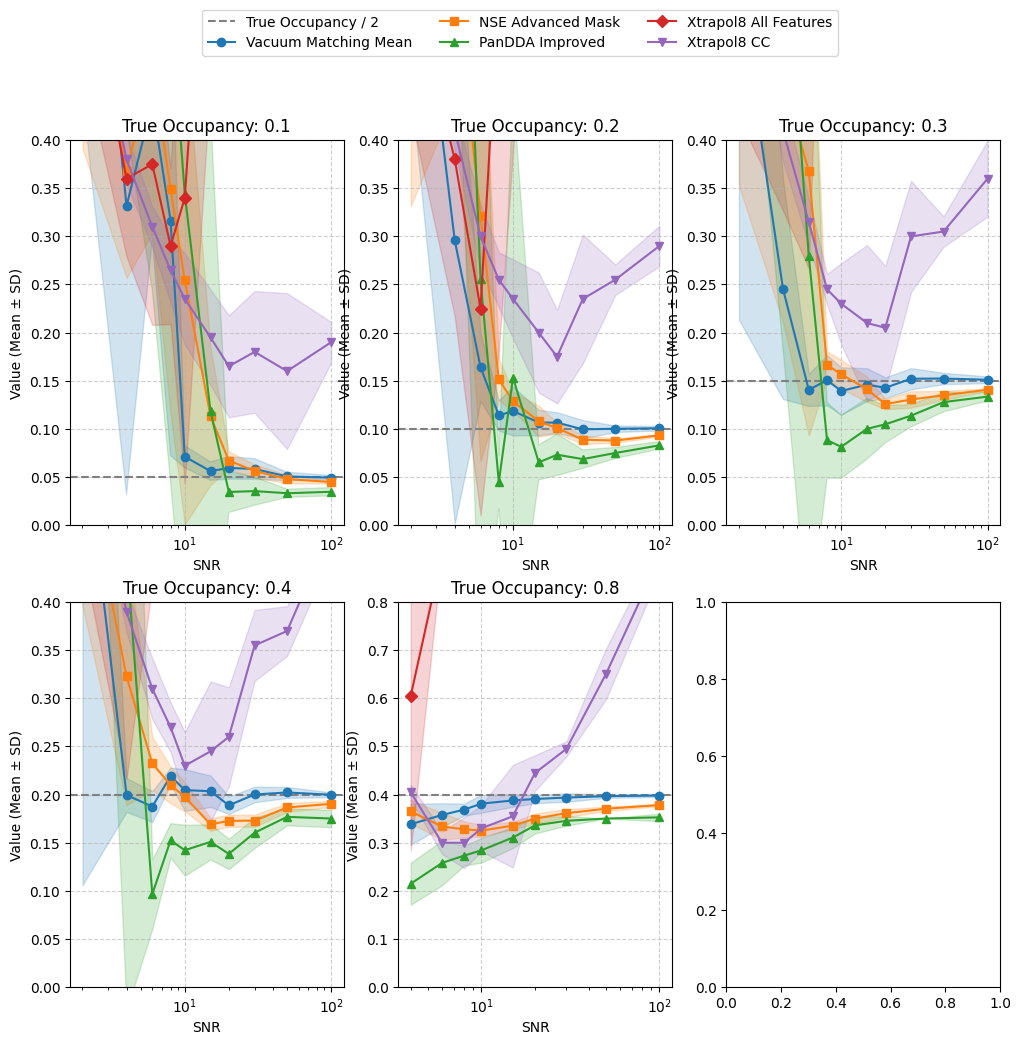

In [9]:
# %matplotlib widget
%matplotlib inline
plt.close('all')
import matplotlib.pyplot as plt
import pandas as pd

# 1. Define your metrics and styling
metrics = ['pandda_imp', 'occ', 'advanced_nse', 'vacuum_mean', 'vacuum_std']
metrics = ['vacuum_mean', 'pandda_imp', 'advanced_nse', 'simple_nse', 'occ']
metrics = ['vacuum_mean',  'panda_trad', 'pandda_imp', 'occ', 'occ_CC', 'simple_nse', 'advanced_nse', ]
metrics = ['vacuum_mean',  'advanced_nse', 'pandda_imp', 'occ', 'occ_CC',] 
# metrics = ['vacuum_mean', 'pandda_imp', 'advanced_nse', 'simple_nse']
# metrics = ['vacuum_mean', 'pandda_imp', 'advanced_nse', 'simple_nse']
real_names = {
    'panda_trad': "PanDDA Original",
    'pandda_imp': "PanDDA Improved",
    'occ': "Xtrapol8 All Features",
    'occ_CC': "Xtrapol8 CC",
    'basic_nse': "NSE Basic Mask",
    'simple_nse': "NSE Basic Mask",
    'advanced_nse': "NSE Advanced Mask",
    'vacuum_mean': "Vacuum Matching Mean",
    'vacuum_std': "Vacuum Matching SD",
}
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
markers = ['o', 's', '^', 'D', 'v', 'x', '*', 'P']
# ds = results_df
# 2. Pre-calculate the Mean and SD
# We group by the facets (occupancy) and the x-axis (snr)
print(ds.columns)
stats = ds.groupby(['true_occupancy', 'snr', 'type'])[metrics].agg(['mean', 'std']).reset_index()
# stats = stats[stats['type'] == 'flat_solvent']
print(stats)

# 3. Create the plot
occupancies = stats['true_occupancy'].unique()
print(occupancies)
# occupancies = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.8]
# if True:
# else:
#     fig, axes = plt.subplots(1, len(occupancies), figsize=(5 * len(occupancies), 5), sharey=False)

# Ensure axes is iterable even if there is only one occupancy
if len(occupancies) == 1:
    fig, axes = plt.subplots(1, 1)
    ax_it = [axes]
else:
    fig, axes = plt.subplots(2, np.sum(np.divmod(len(occupancies),2)) , figsize=(5 * len(occupancies)//2, 11), sharey=False)
    ax_it = axes.flat

ax = ax_it[0]
for i, occ_val in enumerate(occupancies):
    ax = ax_it[i]
    subset = stats[stats['true_occupancy'] == occ_val]
    ax.axhline(occ_val/2, color='gray', linestyle='--', label='True Occupancy / 2')
    
    for j, metric in enumerate(metrics):

        ax.plot(
            subset['snr'], 
            subset[metric]['mean'], 
            # yerr=subset[metric]['std'],
            label=real_names[metric],
            color=colors[j],
            marker=markers[j],
            # capsize=4,      # Adds horizontal lines to the top/bottom of error bars
            linestyle='-',  # Connects the means with a line
            markersize=6
        )
        ax.fill_between(
            subset['snr'], 
            subset[metric]['mean'] -  subset[metric]['std'],
            subset[metric]['mean'] +  subset[metric]['std'],
            # label=metric,
            alpha=0.2,
            color=colors[j],
            # marker=markers[j],
            # capsize=4,      # Adds horizontal lines to the top/bottom of error bars
            # linestyle='-',  # Connects the means with a line
            # markersize=6
        )
    
    ax.set_title(f'True Occupancy: {occ_val}')
    ax.set_xlabel('SNR')
    ax.set_ylabel('Value (Mean ± SD)')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.set_ylim(0,occ_val)
    ax.set_ylim(0,max(.4, occ_val))
    # ax.set_xlim(0,35
    #             )
    ax.set_xscale('log')  # Set x-axis to logarithmic scale for better spacing of SNR values

# Add a single legend for the whole figure

handles, labels = ax.get_legend_handles_labels()
print("handles: ", labels)
handles, labels = ax_it[0].get_legend_handles_labels()
print("handles: ", labels)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.005), ncol=3)
# plt.tight_layout()
if False:
    from configuration import load_figurepath
    loc = load_figurepath()
    fileloc = loc + "combined_metrics.png"
    print('saving to ', fileloc)
    fig.savefig(fileloc, dpi=300, bbox_inches='tight')

plt.show()

saving to  /Users/sbielfel/Dropbox/Apps/Overleaf/Occupancy Determination/figs/uncertainty_metric_evaluation.png


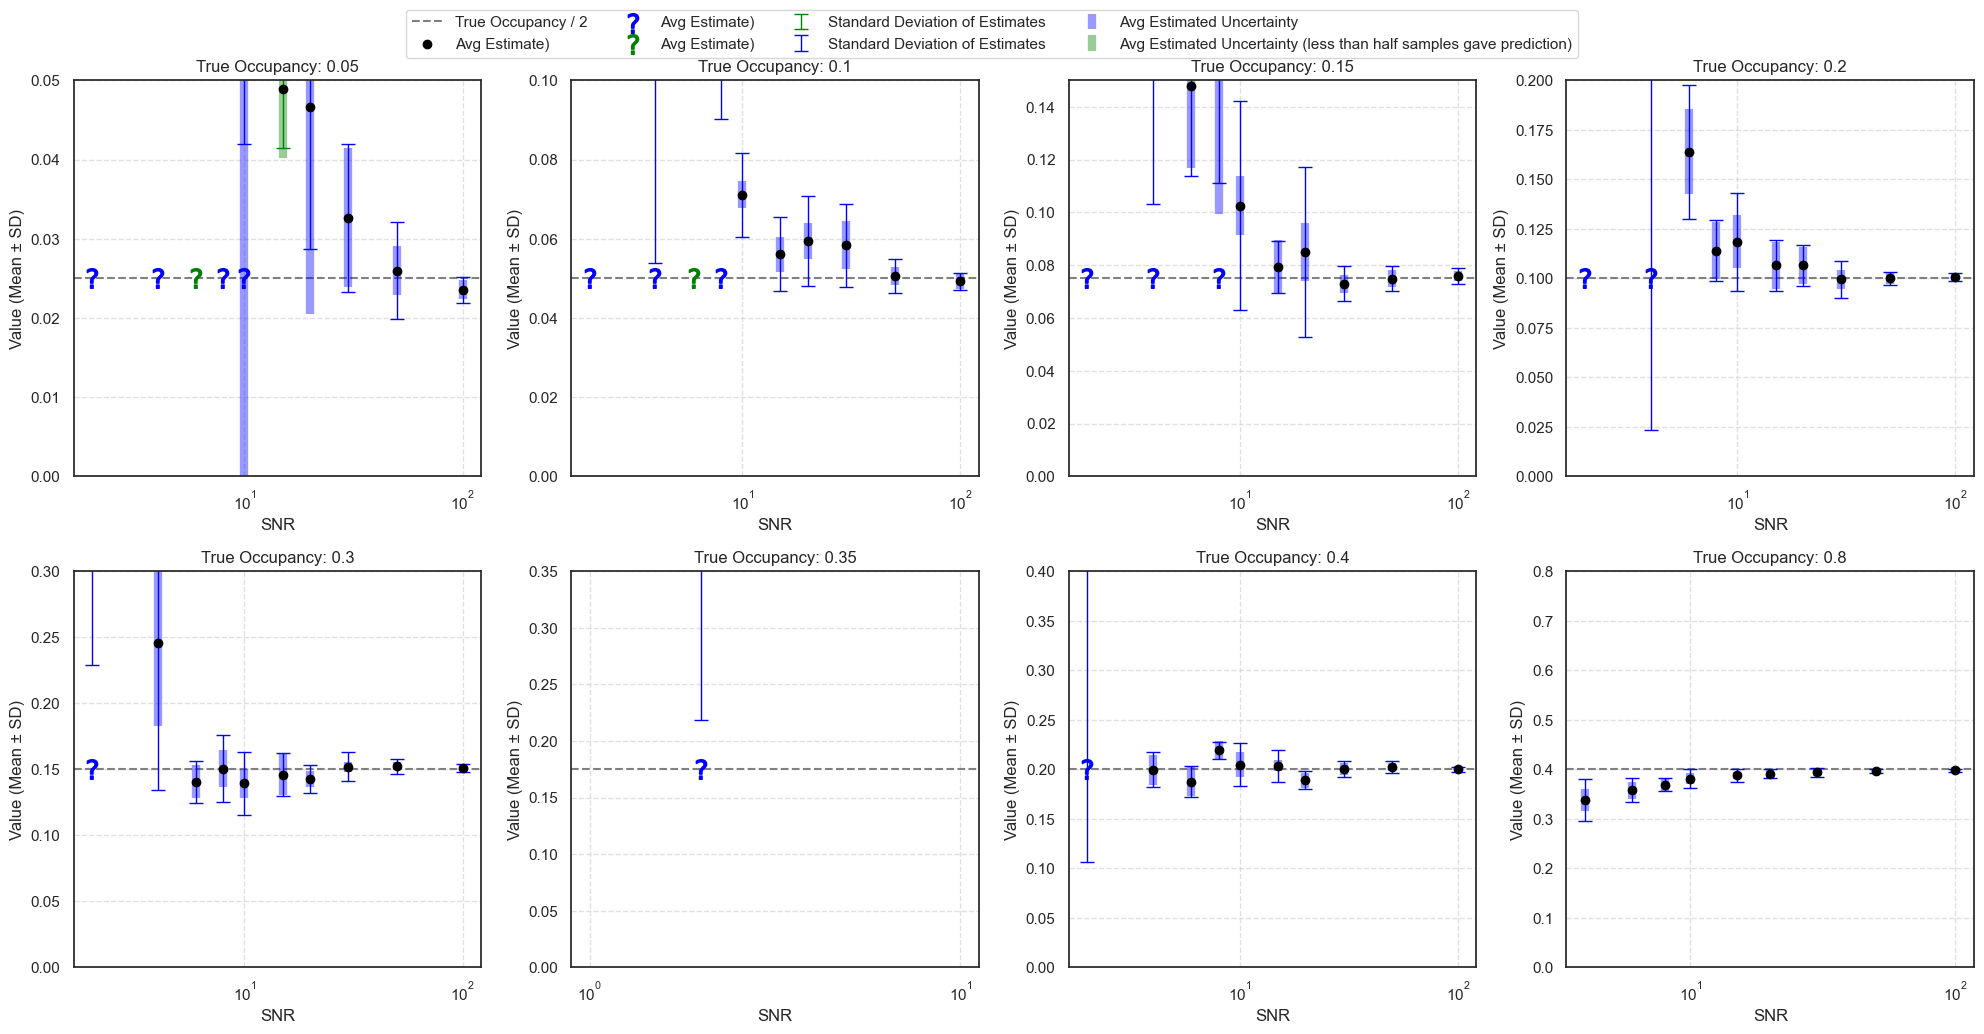

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

all_metrics = [ "panda_trad", "pandda_imp", "occ", "occ_CC", "simple_nse", "advanced_nse", "vacuum_mean", "vacuum_std" ]
# 1. Define your metrics and styling
metrics = [ "vacuum_mean" ]

# 2. Pre-calculate the Mean and SD
# We group by the facets (occupancy) and the x-axis (snr)
stats = ( ds.groupby(["true_occupancy", "snr"])[all_metrics].agg(["mean", "std", "count"]).reset_index())

# 3. Create the plot
occupancies = stats["true_occupancy"].unique()
# occupancies = [0.05, 0.1,0.15, 0.2, 0.3, 0.4]

if True:
    fig, axes = plt.subplots(
        2, len(occupancies) // 2, figsize=(5 * len(occupancies) // 2, 10), sharey=False
    )

# Ensure axes is iterable even if there is only one occupancy
if len(occupancies) == 1:
    axes = [axes]

for i, occ_val in enumerate(occupancies):
    ax = axes.flat[i]
    subset = stats[stats["true_occupancy"] == occ_val]
    ax.axhline(occ_val / 2, color="gray", linestyle="--", label="True Occupancy / 2")
    ymax = max(0.2, occ_val)


    labels = subset["snr"]
    vacuum_mean = subset["vacuum_mean"]["mean"]
    count = subset["vacuum_mean"]["count"]
    uncertainty=subset["vacuum_std"]["mean"]
    st_dev=subset["vacuum_mean"]["std"]

    out_of_sight = ymax<vacuum_mean
    mask = count>5
    zmask = np.logical_and(out_of_sight, mask)
    invzmask = np.logical_and(out_of_sight, ~mask)
    ax.scatter(
        labels, vacuum_mean, 
        color='black', zorder=3, label='Avg Estimate)')
    ax.scatter(
        labels[zmask], np.ones_like(vacuum_mean)[zmask]*occ_val/2, 
        color='blue', marker = '$?$', zorder=3, s=200, label='Avg Estimate)')
    ax.scatter(
        labels[invzmask], np.ones_like(vacuum_mean)[invzmask]*occ_val/2, 
        color='green', marker = '$?$', zorder=10, s=200, label='Avg Estimate)')



    # 2. Plot Standard Deviation (Thin whiskers)
    # ax.errorbar(labels, vacuum_mean, yerr=st_dev, fmt='none', ecolor='gray', 
    #             lw=1, capsize=5, label='Standard Deviation of Estimates')

    # 3. Plot Estimated Uncertainty (Thicker, semi-transparent bars)
    ax.errorbar(labels[~mask], vacuum_mean[~mask], yerr=st_dev[~mask], 
                fmt='none', ecolor='green', 
                lw=1, capsize=5, label='Standard Deviation of Estimates')
    ax.errorbar(labels[mask], vacuum_mean[mask], yerr=st_dev[mask], 
                fmt='none', ecolor='blue', 
                lw=1, capsize=5, label='Standard Deviation of Estimates')

    ax.errorbar(labels[mask], vacuum_mean[mask], yerr=uncertainty[mask], 
                fmt='none', ecolor='blue', 
                lw=6, alpha=0.4, label='Avg Estimated Uncertainty')
    ax.errorbar(labels[~mask], vacuum_mean[~mask], yerr=uncertainty[~mask],
                 fmt='none', ecolor='green', 
                lw=6, alpha=0.4, label='Avg Estimated Uncertainty (less than half samples gave prediction)')

    ax.set_title(f"True Occupancy: {occ_val}")
    ax.set_xlabel("SNR")
    ax.set_ylabel("Value (Mean ± SD)")
    ax.grid(True, linestyle="--", alpha=0.6)
    # ax.set_ylim(0, occ_val)
    # ax.set_ylim(0, ymax)
    # ax.set_xlim(0, 35)
    ax.set_ylim(0, occ_val)
    ax.set_xscale('log')  # Set x-axis to logarithmic scale for better spacing of SNR values

# Add a single legend for the whole figure
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=4)

plt.tight_layout()
if True:
    from configuration import load_figurepath
    loc = load_figurepath()
    fileloc = loc + "uncertainty_metric_evaluation.png"
    print('saving to ', fileloc)
    fig.savefig(fileloc, dpi=300, bbox_inches='tight')
plt.show()

   true_occupancy  snr  vacuum_mean  dev_1  dev_2  dev_3
0            0.05    2           10    0.0    2.0    2.0
1            0.05    4            6    0.0    0.0    0.0
2            0.05    6            4    0.0    0.0    4.0
3            0.05    8            6    0.0    2.0    2.0
4            0.05   10            8    2.0    2.0    2.0
5            0.05   15            4    0.0    0.0    2.0
6            0.05   20           12    2.0    2.0    2.0
7            0.05   30           16    8.0   10.0   10.0
8            0.05   50           18    6.0    8.0   10.0
9            0.05  100           20    8.0   14.0   16.0
   true_occupancy  snr  vacuum_mean  dev_1  dev_2  dev_3
0             0.1    2            6    0.0    0.0    2.0
1             0.1    4            8    0.0    0.0    4.0
2             0.1    6            4    0.0    0.0    0.0
3             0.1    8            8    4.0    4.0    4.0
4             0.1   10            8    0.0    0.0    0.0
5             0.1   15         

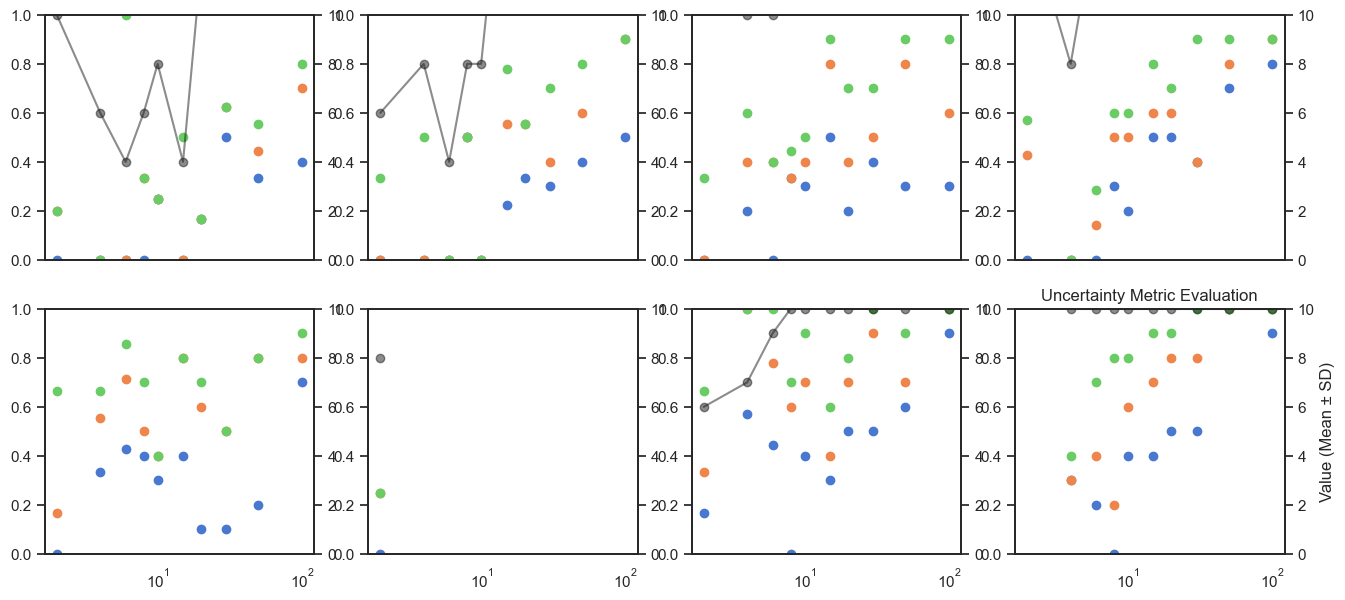

In [ ]:
loc = len(occupancies)
ds['bias'] = np.abs(ds['true_occupancy']/2 - ds['vacuum_mean']) 
col_names = []
for i in range(1,4):
    col_name = 'dev_' + str(i)
    ds[col_name] = ds['bias'] < i*ds['vacuum_std']
    ds[col_name] = ds[col_name].astype(float)
    col_names.append(col_name)
static = ds.groupby(['true_occupancy', 'snr'])[col_names].sum().reset_index()
# static = ds.groupby(['true_occupancy', 'snr'])[col_names].mean().reset_index()
count_vac = ds.groupby(['true_occupancy', 'snr'])['vacuum_mean'].count().reset_index()
fig, axs = plt.subplots(2,loc//2+loc%2,  figsize=(4*len(occupancies)//2, 7), sharex=True)
for i, occ_val in enumerate(occupancies):
    subset = static[static["true_occupancy"] == occ_val]
    ax = axs.flat[i]
    # ax.axhline(occ_val/2, color='gray', linestyle='--', label='True Occupancy / 2')
    # vacuum_mean = subset["vacuum_mean"]
    # vacuum_std = subset["vacuum_std"]
    # bias = np.abs(occ_val - vacuum_mean)
    # success = np.sum(bias<vacuum_std)/np.sum(~np.isnan(bias))
    ax2 = ax.twinx()
    
    cv = count_vac[count_vac["true_occupancy"] == occ_val]
    print(pd.DataFrame(cv).merge(subset, on=['snr', 'true_occupancy']))
    ax2.plot(
        cv["snr"],
        cv["vacuum_mean"],
        "-o",
        color="k",
        alpha=0.5,
        # label=f"Bias for Occupancy {occ_val}",
    )
    for col_name in col_names:
        ax.plot(
            subset["snr"],
            subset[col_name]/cv["vacuum_mean"],
            # subset[col_name],
            # fmt="o",
            "o",
            label=f"Occupancy {occ_val}",
        )
    ax.set_xscale("log")
    ax2.set_ylim(0,10)
    ax.set_ylim(0,1)
    # ax.set_ylim(0, max(occ_val, 0.4))

plt.xlabel("SNR")
plt.ylabel("Value (Mean ± SD)")
plt.title("Uncertainty Metric Evaluation")
plt.show()

In [ ]:
ds

,type,snr,true_occupancy,attempt_no,panda_trad,pandda_imp,occ,occ_CC,simple_nse,advanced_nse,vacuum_mean,vacuum_std,correct_deviation,bias
0,floor,2,0.05,0,1.000000,1.000000,0.6,0.70,0.541948,0.606924,NaN,NaN,0.0,NaN
1,floor,2,0.05,1,1.000000,1.000000,0.5,0.60,0.607000,0.626634,1.513749,0.366113,0.0,1.463749
2,floor,2,0.05,2,1.000000,1.000000,0.6,0.60,0.558208,0.617766,NaN,NaN,0.0,NaN
3,floor,2,0.05,3,1.000000,1.000000,0.4,0.60,0.381226,0.454701,NaN,NaN,0.0,NaN
4,floor,2,0.05,4,1.000000,1.000000,0.6,0.60,0.545264,0.521491,1.843766,0.181758,0.0,1.793766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,floor,100,0.40,5,0.081673,0.183722,0.8,0.45,0.145954,0.192976,0.200846,0.002884,0.0,0.199154
605,floor,100,0.40,6,0.081673,0.166646,0.7,0.50,0.142351,0.187348,0.197639,0.002614,0.0,0.202361
606,floor,100,0.40,7,0.081673,0.166646,0.8,0.45,0.146103,0.192213,0.201017,0.003092,0.0,0.198983
607,floor,100,0.40,8,0.081673,0.166646,0.8,0.45,0.147858,0.195903,0.199697,0.005857,0.0,0.200303


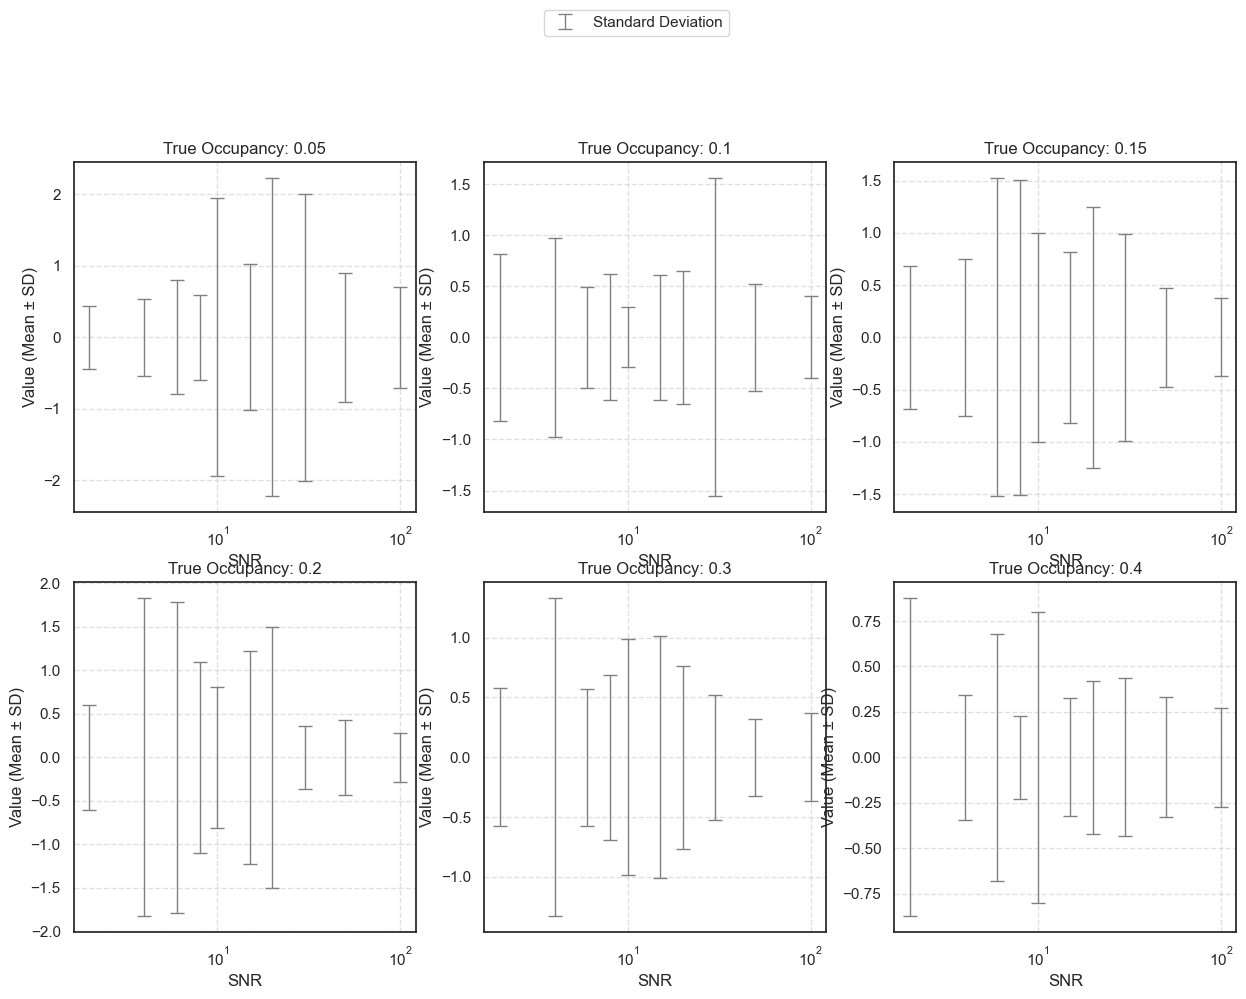

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

all_metrics = [ "panda_trad", "pandda_imp", "occ", "occ_CC", "simple_nse", "advanced_nse", "vacuum_mean", "vacuum_std" ]
# 1. Define your metrics and styling
metrics = [ "vacuum_mean" ]

# 2. Pre-calculate the Mean and SD
# We group by the facets (occupancy) and the x-axis (snr)
stats = ( ds.groupby(["true_occupancy", "snr"])[all_metrics].agg(["mean", "std"]).reset_index())
stats = ( ds.groupby(["true_occupancy", "snr"])[all_metrics].agg(["mean", "std"]).reset_index())

# 3. Create the plot
occupancies = stats["true_occupancy"].unique()
occupancies = [0.05, 0.1,0.15, 0.2, 0.3, 0.4]

if True:
    fig, axes = plt.subplots(
        2, len(occupancies) // 2, figsize=(5 * len(occupancies) // 2, 10), sharey=False
    )

# Ensure axes is iterable even if there is only one occupancy
if len(occupancies) == 1:
    axes = [axes]

for i, occ_val in enumerate(occupancies):
    ax = axes.flat[i]
    subset = stats[stats["true_occupancy"] == occ_val]
    labels = subset["snr"]

    vacuum_mean = subset["vacuum_mean"]["mean"]
    st_dev=subset["vacuum_std"]["mean"]
    st_dev2=subset["vacuum_std"]["std"]
    uncertainty=subset["vacuum_mean"]["std"]
    # ax.scatter(
    #     labels, bias, 
    #     color='black', zorder=3, label='Avg Estimate)')

    # 2. Plot Standard Deviation (Thin whiskers)
    ax.errorbar(labels, np.zeros_like(st_dev), yerr=st_dev2/st_dev, fmt='none', ecolor='gray', 
                lw=1, capsize=5, label='Standard Deviation')

    # 3. Plot Estimated Uncertainty (Thicker, semi-transparent bars)
    # ax.errorbar(labels, bias, yerr=uncertainty, fmt='none', ecolor='blue', 
    #             lw=6, alpha=0.4, label='Avg Estimated Uncertainty')

    ax.set_title(f"True Occupancy: {occ_val}")
    ax.set_xlabel("SNR")
    ax.set_ylabel("Value (Mean ± SD)")
    ax.grid(True, linestyle="--", alpha=0.6)

    # ax.set_ylim(0, occ_val)
    # ax.set_ylim(0, max(0.2, occ_val))
    # ax.set_xlim(0, 35)
    # ax.set_ylim(0, occ_val)
    ax.set_xscale('log')  # Set x-axis to logarithmic scale for better spacing of SNR values

# Add a single legend for the whole figure
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=4)


In [ ]:
ds.groupby(["true_occupancy", "snr"]).count().head(40)

type  attempt_no  panda_trad  pandda_imp  occ  occ_CC  \
true_occupancy snr                                                          
0.05           2      10          10          10          10   10      10   
               4      10          10          10          10   10      10   
               6      10          10          10          10   10      10   
               8      10          10          10          10   10      10   
               10     10          10          10          10   10      10   
               15     10          10          10          10   10      10   
               20     10          10          10          10   10      10   
               30     10          10          10          10   10      10   
               50     10          10          10          10   10      10   
               100    10          10          10          10   10      10   
0.10           2      10          10          10          10   10      10   
               4      10          10          10          10   10      10   
               6      10          10          10          10   10      10   
               8      10          10          10          10   10      10   
               10     10          10          10          10   10      10   
               15     10          10          10          10   10      10   
               20     10          10          10          10   10      10   
               30     10          10          10          10   10      10   
               50     10          10          10          10   10      10   
               100    10          10          10          10   10      10   
0.15           2      10          10          10          10   10      10   
               4      10          10          10          10   10      10   
               6      10          10          10          10   10      10   
               8      10          10          10          10   10      10   
               10     10          10          10          10   10      10   
               15     10          10          10          10   10      10   
               20     10          10          10          10   10      10   
               30     10          10          10          10   10      10   
               50     10          10          10          10   10      10   
               100    10          10          10          10   10      10   
0.20           2      10          10          10          10   10      10   
               4      10          10          10          10   10      10   
               6      10          10          10          10   10      10   
               8      10          10          10          10   10      10   
               10     10          10          10          10   10      10   
               15     10          10          10          10   10      10   
               20     10          10          10          10   10      10   
               30     10          10          10          10   10      10   
               50     10          10          10          10   10      10   
               100    10          10          10          10   10      10   

                    simple_nse  advanced_nse  vacuum_mean  vacuum_std  
true_occupancy snr                                                     
0.05           2            10            10            5           5  
               4            10             8            3           3  
               6            10            10            2           2  
               8            10             9            3           3  
               10           10             9            4           4  
               15           10             7            2           2  
               20           10             9            6           6  
               30           10             9            8           8  
               50           10            10            9        

IndexError: index 6 is out of bounds for axis 0 with size 6

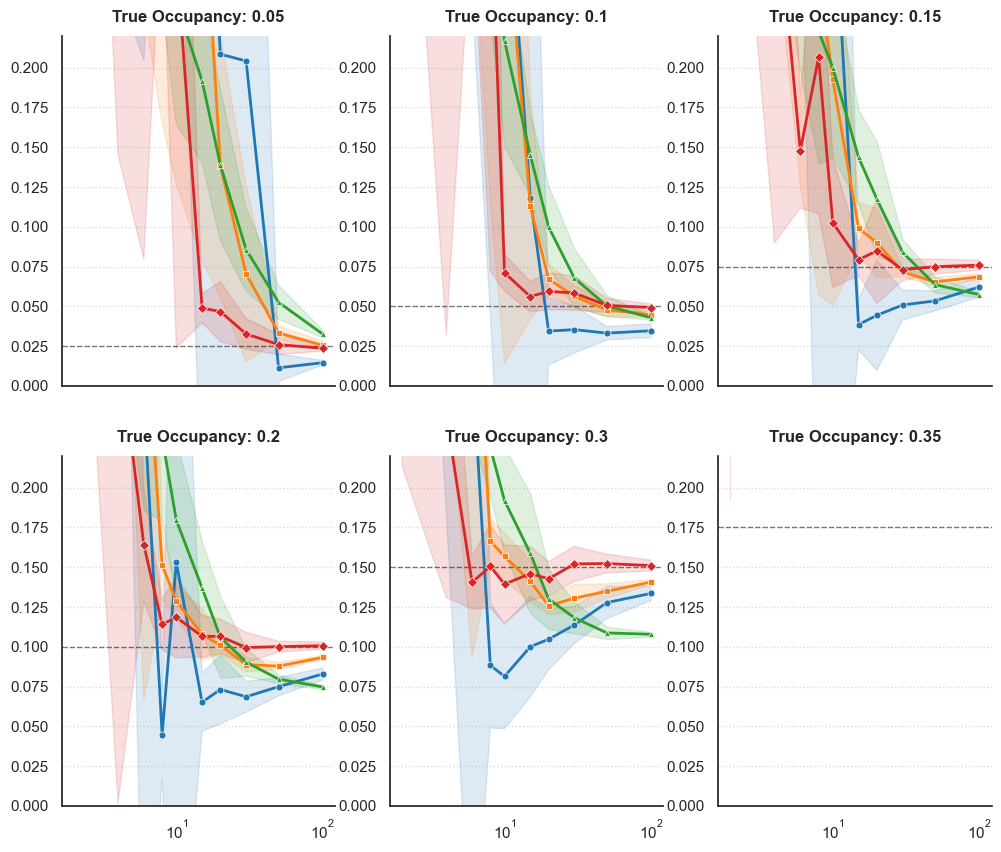

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = [ 'vacuum_mean',]

# Set a professional style
sns.set_theme(style="white", palette="muted") 
plt.rcParams['font.family'] = 'sans-serif'

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axes_flat = axes.flatten()

for i, occ_val in enumerate(occupancies):
    ax = axes_flat[i]
    subset = stats[stats['true_occupancy'] == occ_val]
    
    # Reference line - make it thinner and cleaner
    ax.axhline(occ_val/2, color='black', lw=1, ls='--', alpha=0.5, label='Target')
    
    for j, metric in enumerate(metrics):
        x = subset['snr']
        y_mean = subset[metric]['mean']
        y_std = subset[metric]['std']
        
        # Plot shaded area for SD instead of error bars
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, color=colors[j], alpha=0.15)
        
        # Plot the main line
        ax.plot(x, y_mean, label=metric, color=colors[j], marker=markers[j], 
                markersize=5, lw=2, markeredgecolor='white', markeredgewidth=0.5)

    # Styling refinements
    ax.set_title(f'True Occupancy: {occ_val}', fontweight='bold', pad=10)
    ax.set_xscale('log')
    ax.set_ylim(0, 0.22) # Slightly higher to avoid clipping
    sns.despine(ax=ax) # Removes top and right borders
    ax.grid(axis='y', linestyle=':', alpha=0.7)

# Global labels
fig.supxlabel('Signal-to-Noise Ratio (SNR)', fontsize=12)
fig.supylabel('Measured Value (Mean ± SD)', fontsize=12)

# Legend: Put it at the bottom for better balance
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
           ncol=5, frameon=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()